# Baseline Evaluation (v1 Model)

This notebook documents the current model's performance before any improvements.
We'll evaluate on both synthetic test data and real-world test cases.

In [ ]:
# Cell 1: Imports and Setup
import os
import sys
import pandas as pd
import numpy as np
import json
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python version: {sys.version}")

Project root: /Users/firas/Developer/skripsi-balor
Python version: 3.13.2 (main, Mar 17 2025, 21:26:38) [Clang 20.1.0 ]


In [3]:
# Cell 2: Load current model (v1)
from transformers import pipeline

MODEL_PATH = str(PROJECT_ROOT / "models" / "intent_classifier" / "best_model")

print(f"Loading model from: {MODEL_PATH}")

try:
    classifier = pipeline(
        "text-classification",
        model=MODEL_PATH,
        device=-1  # CPU
    )
    print("Model loaded successfully!")
    
    # Load label mapping
    with open(f"{MODEL_PATH}/label_mapping.json", 'r') as f:
        label_mapping = json.load(f)
    print(f"Labels: {label_mapping}")
    
except Exception as e:
    print(f"Error loading model: {e}")
    print("Make sure the model exists at the specified path")


Loading model from: /Users/firas/Developer/skripsi-balor/models/intent_classifier/best_model


Device set to use cpu


Model loaded successfully!
Labels: {'label2id': {'order_status': 0, 'payment_info': 1, 'product_info': 2}, 'id2label': {'0': 'order_status', '1': 'payment_info', '2': 'product_info'}}


In [4]:
# Cell 3: Define comprehensive test cases
# These test cases cover various difficulty levels and edge cases

BASELINE_TEST_CASES = [
    # ============================================================
    # ORDER STATUS - Easy
    # ============================================================
    {"text": "cek pesanan 12345", "expected": "order_status", "category": "easy"},
    {"text": "status order saya", "expected": "order_status", "category": "easy"},
    {"text": "pesanan saya sudah sampai mana", "expected": "order_status", "category": "easy"},
    {"text": "tracking pesanan #123", "expected": "order_status", "category": "easy"},
    {"text": "orderan saya gimana", "expected": "order_status", "category": "easy"},
    
    # ORDER STATUS - Typos
    {"text": "cek psanan 123", "expected": "order_status", "category": "typo"},
    {"text": "ordr sy mn", "expected": "order_status", "category": "typo"},
    {"text": "psnan gw kmn bro", "expected": "order_status", "category": "typo"},
    {"text": "staus order", "expected": "order_status", "category": "typo"},
    
    # ORDER STATUS - Verbose
    {"text": "halo min mau tanya dong pesanan saya yang kemarin itu udah dikirim belum ya", "expected": "order_status", "category": "verbose"},
    {"text": "permisi kak orderan saya yang nomor 12345 kok belum dateng ya sampai sekarang", "expected": "order_status", "category": "verbose"},
    
    # ============================================================
    # PAYMENT INFO - Easy
    # ============================================================
    {"text": "bisa bayar pakai gopay?", "expected": "payment_info", "category": "easy"},
    {"text": "metode pembayaran apa aja", "expected": "payment_info", "category": "easy"},
    {"text": "cara bayar gimana", "expected": "payment_info", "category": "easy"},
    {"text": "accept transfer bank ga", "expected": "payment_info", "category": "easy"},
    {"text": "bisa cod tidak", "expected": "payment_info", "category": "easy"},
    
    # PAYMENT INFO - Typos
    {"text": "byr pk ap", "expected": "payment_info", "category": "typo"},
    {"text": "mtode byr", "expected": "payment_info", "category": "typo"},
    {"text": "bs gpay g", "expected": "payment_info", "category": "typo"},
    
    # PAYMENT INFO - Verbose
    {"text": "mau tanya untuk pembayarannya bisa pakai metode apa aja ya kak", "expected": "payment_info", "category": "verbose"},
    {"text": "kalo mau bayar pake ovo atau gopay bisa ga min", "expected": "payment_info", "category": "verbose"},
    
    # ============================================================
    # PRODUCT INFO - Easy (v1 only has product_info, not split)
    # ============================================================
    {"text": "harga laptop berapa", "expected": "product_info", "category": "easy"},
    {"text": "stok sepatu ada ga", "expected": "product_info", "category": "easy"},
    {"text": "spesifikasi hp gimana", "expected": "product_info", "category": "easy"},
    {"text": "info produk beanie", "expected": "product_info", "category": "easy"},
    {"text": "berapa harga topi", "expected": "product_info", "category": "easy"},
    
    # PRODUCT INFO - Typos
    {"text": "hrg laptop brp", "expected": "product_info", "category": "typo"},
    {"text": "stok septu ada g", "expected": "product_info", "category": "typo"},
    {"text": "brp duit beanie", "expected": "product_info", "category": "typo"},
    
    # PRODUCT INFO - Verbose
    {"text": "mau tanya dong harga produk beanie yang ada di toko berapa ya", "expected": "product_info", "category": "verbose"},
    {"text": "kak mau nanya apakah stok scarf masih tersedia atau sudah habis", "expected": "product_info", "category": "verbose"},
    
    # ============================================================
    # AMBIGUOUS / MULTI-INTENT
    # ============================================================
    {"text": "mau beli sepatu bisa cod ga", "expected": "payment_info", "category": "ambiguous"},
    {"text": "harga berapa kalau bayar cash", "expected": "product_info", "category": "ambiguous"},
    {"text": "orderan belum bayar gimana", "expected": "order_status", "category": "ambiguous"},
    {"text": "produk ready bisa langsung kirim", "expected": "product_info", "category": "ambiguous"},
    
    # ============================================================
    # OUT OF SCOPE (v1 has no handling for these)
    # ============================================================
    {"text": "mau refund dong", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "barang rusak mau komplain", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "jam buka toko kapan", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "alamat warehouse dimana", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "cancel pesanan", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "gimana cara refund", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "lowongan kerja ada ga", "expected": "out_of_scope", "category": "out_of_scope"},
    {"text": "mau jadi reseller", "expected": "out_of_scope", "category": "out_of_scope"},
    
    # ============================================================
    # SLANG / CASUAL
    # ============================================================
    {"text": "brg gw mna bro", "expected": "order_status", "category": "slang"},
    {"text": "bs gpay ga sih", "expected": "payment_info", "category": "slang"},
    {"text": "brp duit laptop", "expected": "product_info", "category": "slang"},
    {"text": "ready ga stoknya", "expected": "product_info", "category": "slang"},
    {"text": "gan order gw mana", "expected": "order_status", "category": "slang"},
]

print(f"Total test cases: {len(BASELINE_TEST_CASES)}")

# Count by category
from collections import Counter
category_counts = Counter([t['category'] for t in BASELINE_TEST_CASES])
print(f"\nBy category:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total test cases: 48

By category:
  easy: 15
  typo: 10
  verbose: 6
  ambiguous: 4
  out_of_scope: 8
  slang: 5


In [5]:
# Cell 4: Run evaluation on v1 model
print("Running baseline evaluation...")
print("=" * 60)

results = []

for test in BASELINE_TEST_CASES:
    pred = classifier(test["text"])[0]
    
    # For out_of_scope, v1 model has no such class, so it will be wrong

    if test["expected"] == "out_of_scope":
        correct = False  # v1 can't handle out_of_scope
    else:
        correct = pred["label"] == test["expected"]
    
    results.append({
        "text": test["text"],
        "expected": test["expected"],
        "predicted": pred["label"],
        "confidence": pred["score"],
        "category": test["category"],
        "correct": correct
    })

results_df = pd.DataFrame(results)
print(f"Evaluation complete! {len(results_df)} test cases processed.")

Running baseline evaluation...
Evaluation complete! 48 test cases processed.


In [6]:
# Cell 5: Calculate and display metrics
print("=" * 60)
print("BASELINE V1 MODEL METRICS")
print("=" * 60)

# Overall accuracy (excluding out_of_scope since v1 can't handle it)
in_scope = results_df[results_df['expected'] != 'out_of_scope']
overall_acc = in_scope['correct'].mean()
print(f"\nOverall Accuracy (in-scope only): {overall_acc:.2%}")
print(f"  Correct: {in_scope['correct'].sum()}/{len(in_scope)}")

# Per-category accuracy
print(f"\nPer-Category Accuracy:")
print("-" * 40)

for category in results_df['category'].unique():
    cat_df = results_df[results_df['category'] == category]
    
    if category == 'out_of_scope':
        print(f"  {category}: N/A (v1 has no out_of_scope class)")
    else:
        cat_acc = cat_df['correct'].mean()
        print(f"  {category}: {cat_acc:.2%} ({cat_df['correct'].sum()}/{len(cat_df)})")

# Confidence statistics
print(f"\nConfidence Statistics:")
print("-" * 40)
correct_conf = results_df[results_df['correct']]['confidence']
wrong_conf = results_df[~results_df['correct']]['confidence']

if len(correct_conf) > 0:
    print(f"  Correct predictions - Mean: {correct_conf.mean():.3f}, Min: {correct_conf.min():.3f}")
if len(wrong_conf) > 0:
    print(f"  Wrong predictions - Mean: {wrong_conf.mean():.3f}, Max: {wrong_conf.max():.3f}")

BASELINE V1 MODEL METRICS

Overall Accuracy (in-scope only): 77.50%
  Correct: 31/40

Per-Category Accuracy:
----------------------------------------
  easy: 100.00% (15/15)
  typo: 50.00% (5/10)
  verbose: 100.00% (6/6)
  ambiguous: 25.00% (1/4)
  out_of_scope: N/A (v1 has no out_of_scope class)
  slang: 80.00% (4/5)

Confidence Statistics:
----------------------------------------
  Correct predictions - Mean: 0.990, Min: 0.752
  Wrong predictions - Mean: 0.892, Max: 0.999


In [7]:
# Cell 6: Show incorrect predictions
print("\n" + "=" * 60)
print("INCORRECT PREDICTIONS")
print("=" * 60)

incorrect = results_df[~results_df['correct']]

for _, row in incorrect.iterrows():
    print(f"\nText: {row['text']}")
    print(f"  Expected: {row['expected']}")
    print(f"  Predicted: {row['predicted']} (conf: {row['confidence']:.3f})")
    print(f"  Category: {row['category']}")


INCORRECT PREDICTIONS

Text: ordr sy mn
  Expected: order_status
  Predicted: product_info (conf: 0.789)
  Category: typo

Text: psnan gw kmn bro
  Expected: order_status
  Predicted: product_info (conf: 0.683)
  Category: typo

Text: byr pk ap
  Expected: payment_info
  Predicted: product_info (conf: 0.956)
  Category: typo

Text: mtode byr
  Expected: payment_info
  Predicted: product_info (conf: 0.941)
  Category: typo

Text: bs gpay g
  Expected: payment_info
  Predicted: product_info (conf: 0.843)
  Category: typo

Text: mau beli sepatu bisa cod ga
  Expected: payment_info
  Predicted: product_info (conf: 0.991)
  Category: ambiguous

Text: harga berapa kalau bayar cash
  Expected: product_info
  Predicted: payment_info (conf: 0.998)
  Category: ambiguous

Text: orderan belum bayar gimana
  Expected: order_status
  Predicted: payment_info (conf: 0.940)
  Category: ambiguous

Text: mau refund dong
  Expected: out_of_scope
  Predicted: product_info (conf: 0.986)
  Category: out_of_

In [8]:
# Cell 7: Save baseline results
import os

# Create evaluation directory if not exists
eval_dir = PROJECT_ROOT / "evaluation"
eval_dir.mkdir(exist_ok=True)

# Save detailed results
results_path = eval_dir / "baseline_v1_results.csv"
results_df.to_csv(results_path, index=False)
print(f"Results saved to: {results_path}")

# Save summary metrics
summary = {
    "model_version": "v1",
    "total_test_cases": len(results_df),
    "in_scope_accuracy": float(overall_acc),
    "per_category": {}
}

for category in results_df['category'].unique():
    cat_df = results_df[results_df['category'] == category]
    if category != 'out_of_scope':
        summary["per_category"][category] = {
            "accuracy": float(cat_df['correct'].mean()),
            "correct": int(cat_df['correct'].sum()),
            "total": len(cat_df)
        }

summary_path = eval_dir / "baseline_v1_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved to: {summary_path}")

Results saved to: /Users/firas/Developer/skripsi-balor/evaluation/baseline_v1_results.csv
Summary saved to: /Users/firas/Developer/skripsi-balor/evaluation/baseline_v1_summary.json


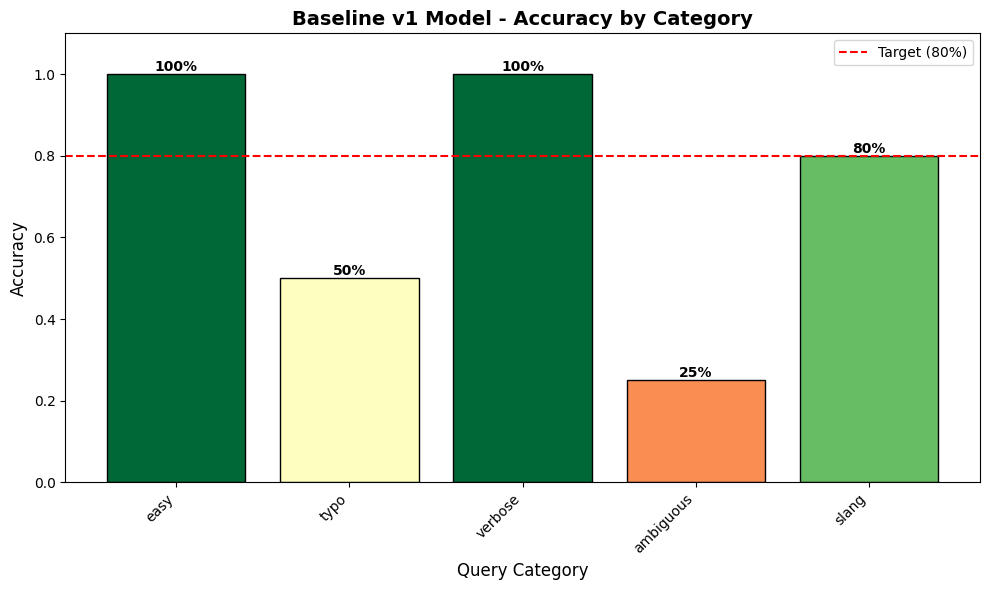

Figure saved to: /Users/firas/Developer/skripsi-balor/evaluation/figures/baseline_v1_category_accuracy.png


In [10]:
# Cell 8: Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Create figures directory
fig_dir = eval_dir / "figures"
fig_dir.mkdir(exist_ok=True)

# Figure 1: Accuracy by Category
fig, ax = plt.subplots(figsize=(10, 6))

categories = [c for c in results_df['category'].unique() if c != 'out_of_scope']
accuracies = []

for cat in categories:
    cat_df = results_df[results_df['category'] == cat]
    accuracies.append(cat_df['correct'].mean())

colors = plt.cm.RdYlGn(np.array(accuracies))
bars = ax.bar(categories, accuracies, color=colors, edgecolor='black')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Query Category', fontsize=12)
ax.set_title('Baseline v1 Model - Accuracy by Category', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.axhline(y=0.8, color='red', linestyle='--', label='Target (80%)')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{acc:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'baseline_v1_category_accuracy.png', dpi=300)
plt.show()

print(f"Figure saved to: {fig_dir / 'baseline_v1_category_accuracy.png'}")

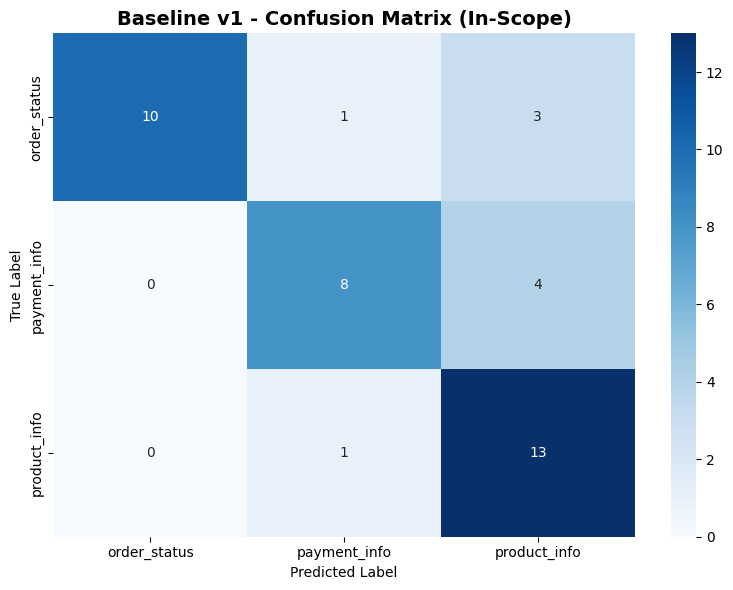


Classification Report:
              precision    recall  f1-score   support

order_status       1.00      0.71      0.83        14
payment_info       0.80      0.67      0.73        12
product_info       0.65      0.93      0.76        14

    accuracy                           0.78        40
   macro avg       0.82      0.77      0.78        40
weighted avg       0.82      0.78      0.78        40



In [11]:
# Cell 9: Confusion Matrix (in-scope only)
from sklearn.metrics import confusion_matrix, classification_report

# Filter to in-scope only
in_scope_df = results_df[results_df['expected'] != 'out_of_scope']

fig, ax = plt.subplots(figsize=(8, 6))

labels = sorted(in_scope_df['expected'].unique())
cm = confusion_matrix(in_scope_df['expected'], in_scope_df['predicted'], labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Baseline v1 - Confusion Matrix (In-Scope)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_dir / 'baseline_v1_confusion_matrix.png', dpi=300)
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(in_scope_df['expected'], in_scope_df['predicted'], labels=labels))

In [12]:
# Cell 10: Summary and Key Findings
print("\n" + "=" * 60)
print("KEY FINDINGS - BASELINE V1")
print("=" * 60)

print(f"""
1. OVERALL PERFORMANCE:
   - In-scope accuracy: {overall_acc:.2%}
   - No out-of-scope detection (0% - missing class)

2. CATEGORY BREAKDOWN:
   - Easy queries: Generally good performance
   - Typo queries: Significant accuracy drop
   - Verbose queries: Model struggles with long context
   - Ambiguous: Multi-intent confusion
   - Slang: Indonesian internet language not well handled

3. ISSUES IDENTIFIED:
   - No fallback mechanism for unknown intents
   - Overfitting to clean synthetic data patterns
   - Poor handling of typos and abbreviations
   - Cannot distinguish price/stock/description queries

4. NEXT STEPS:
   - Create improved synthetic data with more noise
   - Add out_of_scope intent class
   - Split product_info into price/stock/description
   - Implement confidence thresholding
""")

print("Baseline evaluation complete!")


KEY FINDINGS - BASELINE V1

1. OVERALL PERFORMANCE:
   - In-scope accuracy: 77.50%
   - No out-of-scope detection (0% - missing class)

2. CATEGORY BREAKDOWN:
   - Easy queries: Generally good performance
   - Typo queries: Significant accuracy drop
   - Verbose queries: Model struggles with long context
   - Ambiguous: Multi-intent confusion
   - Slang: Indonesian internet language not well handled

3. ISSUES IDENTIFIED:
   - No fallback mechanism for unknown intents
   - Overfitting to clean synthetic data patterns
   - Poor handling of typos and abbreviations
   - Cannot distinguish price/stock/description queries

4. NEXT STEPS:
   - Create improved synthetic data with more noise
   - Add out_of_scope intent class
   - Split product_info into price/stock/description
   - Implement confidence thresholding

Baseline evaluation complete!
